In [ ]:
#https://www.kaggle.com/datasets/adarsh0806/ab-testing-practice

In [ ]:
!pip install pandas

### Немного про словари

In [1]:
import numpy as np

sample = np.array([46.76, 45.98, 45.82, 44.72, 46.13, 
                   47.99, 44.60, 45.81, 44.91, 44.95])

regions = np.array(["Республика Алтай", "Республика Тыва",
           "Республика Хакасия", "Алтайский край",
           "Красноярский край", "Иркутская область",
           "Кемеровская область", "Новосибирская область",
           "Омская область", "Томская область"])

In [3]:
print(*zip(regions, sample))

('Республика Алтай', 46.76) ('Республика Тыва', 45.98) ('Республика Хакасия', 45.82) ('Алтайский край', 44.72) ('Красноярский край', 46.13) ('Иркутская область', 47.99) ('Кемеровская область', 44.6) ('Новосибирская область', 45.81) ('Омская область', 44.91) ('Томская область', 44.95)


In [5]:
D = dict(zip(regions, sample))

In [7]:
print(D["Республика Алтай"])

46.76


In [8]:
print(D.keys())
print(D.values())

dict_keys(['Республика Алтай', 'Республика Тыва', 'Республика Хакасия', 'Алтайский край', 'Красноярский край', 'Иркутская область', 'Кемеровская область', 'Новосибирская область', 'Омская область', 'Томская область'])
dict_values([46.76, 45.98, 45.82, 44.72, 46.13, 47.99, 44.6, 45.81, 44.91, 44.95])


In [9]:
print(D.items())

dict_items([('Республика Алтай', 46.76), ('Республика Тыва', 45.98), ('Республика Хакасия', 45.82), ('Алтайский край', 44.72), ('Красноярский край', 46.13), ('Иркутская область', 47.99), ('Кемеровская область', 44.6), ('Новосибирская область', 45.81), ('Омская область', 44.91), ('Томская область', 44.95)])


In [10]:
for reg, price in D.items():
    print(f"Средняя цена в регионе {reg} равна {price}.")

Средняя цена в регионе Республика Алтай равна 46.76.
Средняя цена в регионе Республика Тыва равна 45.98.
Средняя цена в регионе Республика Хакасия равна 45.82.
Средняя цена в регионе Алтайский край равна 44.72.
Средняя цена в регионе Красноярский край равна 46.13.
Средняя цена в регионе Иркутская область равна 47.99.
Средняя цена в регионе Кемеровская область равна 44.6.
Средняя цена в регионе Новосибирская область равна 45.81.
Средняя цена в регионе Омская область равна 44.91.
Средняя цена в регионе Томская область равна 44.95.


### Последовательность Pandas Series и датафрейм Pandas DataFrame

In [13]:
import pandas as pd

info = pd.Series(sample)
print(info)

0    46.76
1    45.98
2    45.82
3    44.72
4    46.13
5    47.99
6    44.60
7    45.81
8    44.91
9    44.95
dtype: float64


In [15]:
print(info.index, type(info.index))
print(info.values, type(info.values))

RangeIndex(start=0, stop=10, step=1) <class 'pandas.core.indexes.range.RangeIndex'>
[46.76 45.98 45.82 44.72 46.13 47.99 44.6  45.81 44.91 44.95] <class 'numpy.ndarray'>


In [16]:
info = pd.Series(sample, index = regions)
print(info)

Республика Алтай        46.76
Республика Тыва          45.98
Республика Хакасия       45.82
Алтайский край        44.72
Красноярский край      46.13
Иркутская область        47.99
Кемеровская область      44.60
Новосибирская область    45.81
Омская область           44.91
Томская область          44.95
dtype: float64


### Загрузка и описание данных

In [17]:
df = pd.read_csv("https://raw.githubusercontent.com/allatambov/PyPerm25/refs/heads/main/ab_testing.csv")

In [18]:
print(df.head())

   User ID Group  Page Views  Time Spent Conversion   Device          Location
0    14292     B           3         424         No   Mobile  Northern Ireland
1    11682     A           9         342         No   Mobile          Scotland
2    19825     A           2         396         No  Desktop  Northern Ireland
3    16080     B           4         318         No  Desktop             Wales
4    18851     A           1         338        Yes  Desktop          Scotland


In [19]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     5000 non-null   int64 
 1   Group       5000 non-null   object
 2   Page Views  5000 non-null   int64 
 3   Time Spent  5000 non-null   int64 
 4   Conversion  5000 non-null   object
 5   Device      5000 non-null   object
 6   Location    5000 non-null   object
dtypes: int64(3), object(4)
memory usage: 273.6+ KB
None


In [21]:
print(df.isna().sum())

User ID       0
Group         0
Page Views    0
Time Spent    0
Conversion    0
Device        0
Location      0
dtype: int64


In [22]:
print(df.describe())

            User ID   Page Views   Time Spent
count   5000.000000  5000.000000  5000.000000
mean   14925.159000     7.537600   242.512600
std     2869.153773     4.022465   118.254153
min    10001.000000     1.000000    40.000000
25%    12456.250000     4.000000   137.000000
50%    14858.500000     8.000000   243.000000
75%    17379.750000    11.000000   346.000000
max    19995.000000    14.000000   449.000000


In [23]:
print(df.describe(include = "object"))

       Group Conversion   Device  Location
count   5000       5000     5000      5000
unique     2          2        2         4
top        A         No  Desktop  Scotland
freq    2519       4515     2538      1281


In [24]:
print(df.describe(include = [int, float]))

            User ID   Page Views   Time Spent
count   5000.000000  5000.000000  5000.000000
mean   14925.159000     7.537600   242.512600
std     2869.153773     4.022465   118.254153
min    10001.000000     1.000000    40.000000
25%    12456.250000     4.000000   137.000000
50%    14858.500000     8.000000   243.000000
75%    17379.750000    11.000000   346.000000
max    19995.000000    14.000000   449.000000


In [25]:
print(df.describe(include = "all"))

             User ID Group   Page Views   Time Spent Conversion   Device  \
count    5000.000000  5000  5000.000000  5000.000000       5000     5000   
unique           NaN     2          NaN          NaN          2        2   
top              NaN     A          NaN          NaN         No  Desktop   
freq             NaN  2519          NaN          NaN       4515     2538   
mean    14925.159000   NaN     7.537600   242.512600        NaN      NaN   
std      2869.153773   NaN     4.022465   118.254153        NaN      NaN   
min     10001.000000   NaN     1.000000    40.000000        NaN      NaN   
25%     12456.250000   NaN     4.000000   137.000000        NaN      NaN   
50%     14858.500000   NaN     8.000000   243.000000        NaN      NaN   
75%     17379.750000   NaN    11.000000   346.000000        NaN      NaN   
max     19995.000000   NaN    14.000000   449.000000        NaN      NaN   

        Location  
count       5000  
unique         4  
top     Scotland  
freq       

In [27]:
# для чего может быть нужен отбор типов

df.select_dtypes([int, float]).corr()

,User ID,Page Views,Time Spent
User ID,1.000000,-0.009423,-0.021288
Page Views,-0.009423,1.000000,-0.001484
Time Spent,-0.021288,-0.001484,1.000000


In [28]:
print(df.columns)
print(df.index)

Index(['User ID', 'Group', 'Page Views', 'Time Spent', 'Conversion', 'Device',
       'Location'],
      dtype='object')
RangeIndex(start=0, stop=5000, step=1)


In [30]:
print(df["Time Spent"], type(df["Time Spent"]))

0       424
1       342
2       396
3       318
4       338
       ... 
4995    313
4996    313
4997    156
4998    346
4999    208
Name: Time Spent, Length: 5000, dtype: int64 <class 'pandas.core.series.Series'>


In [31]:
print(df["Time Spent"].index)
print(df["Time Spent"].values)

RangeIndex(start=0, stop=5000, step=1)
[424 342 396 ... 156 346 208]


### Работа со столбцами датафрейма: добавление и описание

In [34]:
df["Time Spent Min"] = df["Time Spent"] / 60
df["Time per View"] = df["Time Spent"] / df["Page Views"]
print(df.head())

   User ID Group  Page Views  Time Spent Conversion   Device  \
0    14292     B           3         424         No   Mobile   
1    11682     A           9         342         No   Mobile   
2    19825     A           2         396         No  Desktop   
3    16080     B           4         318         No  Desktop   
4    18851     A           1         338        Yes  Desktop   

           Location  Time Spent Min  Time per View  
0  Northern Ireland        7.066667     141.333333  
1          Scotland        5.700000      38.000000  
2  Northern Ireland        6.600000     198.000000  
3             Wales        5.300000      79.500000  
4          Scotland        5.633333     338.000000  


In [35]:
print(df["Time Spent"].describe())

count    5000.000000
mean      242.512600
std       118.254153
min        40.000000
25%       137.000000
50%       243.000000
75%       346.000000
max       449.000000
Name: Time Spent, dtype: float64


In [36]:
print(df["Time Spent"].mean())
print(df["Time Spent"].median())
print(df["Time Spent"].std())

242.5126
243.0
118.25415278192153


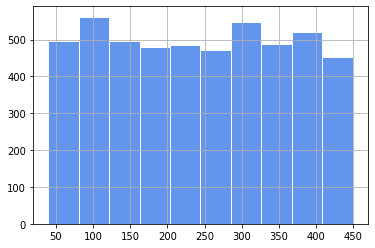

In [40]:
df["Time Spent"].hist(color = "cornflowerblue", edgecolor = "w");

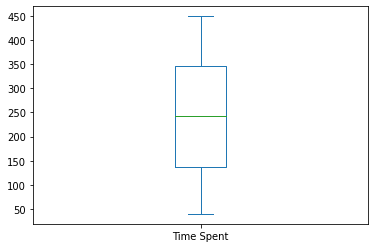

In [41]:
df["Time Spent"].plot.box();

In [42]:
print(df["Location"].describe())

count         5000
unique           4
top       Scotland
freq          1281
Name: Location, dtype: object


In [43]:
print(df["Location"].unique())

['Northern Ireland' 'Scotland' 'Wales' 'England']


In [45]:
print(sorted(df["Location"].unique()))

['England', 'Northern Ireland', 'Scotland', 'Wales']


In [46]:
print(df["Location"].mode())

0    Scotland
dtype: object


In [47]:
print(df["Location"].mode()[0])

Scotland


In [48]:
print(df["Location"].value_counts())

Scotland            1281
England             1246
Northern Ireland    1242
Wales               1231
Name: Location, dtype: int64


In [49]:
print(df["Location"].value_counts(normalize = True))

Scotland            0.2562
England             0.2492
Northern Ireland    0.2484
Wales               0.2462
Name: Location, dtype: float64


In [51]:
print(df["Location"].value_counts(normalize = True) * 100)

Scotland            25.62
England             24.92
Northern Ireland    24.84
Wales               24.62
Name: Location, dtype: float64


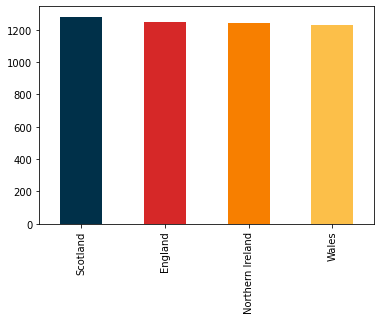

In [53]:
#https://coolors.co/palettes/trending

bars = ["#003049", "#D62828", "#F77F00", "#FCBF49"]
df["Location"].value_counts().plot.bar(color = bars);

### Работа со столбцами датафрейма: создание новых столбцов на основе старых

In [57]:
df["Conversion"] = (df["Conversion"] == "Yes").astype(int)

In [60]:
df["Group"] = df["Group"].replace({"A" : "Control", "B" : "Treatment"})

In [63]:
print(df["Page Views"].apply(lambda x: 1 if x >= 4 else 0))

0       0
1       1
2       0
3       1
4       0
       ..
4995    1
4996    1
4997    1
4998    1
4999    1
Name: Page Views, Length: 5000, dtype: int64


In [66]:
df.drop(columns = ["Page Views", "Time Spent Min", 
                  "Time per View"], inplace = True)

In [68]:
print(df.head(10)) # df.tail(10)

   User ID      Group  Time Spent  Conversion   Device          Location
0    14292  Treatment         424           0   Mobile  Northern Ireland
1    11682    Control         342           0   Mobile          Scotland
2    19825    Control         396           0  Desktop  Northern Ireland
3    16080  Treatment         318           0  Desktop             Wales
4    18851    Control         338           1  Desktop          Scotland
5    13134  Treatment          93           0  Desktop          Scotland
6    16702    Control         106           0   Mobile  Northern Ireland
7    10041  Treatment         292           0   Mobile  Northern Ireland
8    13191  Treatment         434           0  Desktop  Northern Ireland
9    14427  Treatment         271           0  Desktop           England


### Переименование и удаление

In [70]:
df.rename(columns = {"User ID" : "ID", "Time Spent": "Time"}, 
          inplace = True)

In [71]:
print(df.head(10))

      ID      Group  Time  Conversion   Device          Location
0  14292  Treatment   424           0   Mobile  Northern Ireland
1  11682    Control   342           0   Mobile          Scotland
2  19825    Control   396           0  Desktop  Northern Ireland
3  16080  Treatment   318           0  Desktop             Wales
4  18851    Control   338           1  Desktop          Scotland
5  13134  Treatment    93           0  Desktop          Scotland
6  16702    Control   106           0   Mobile  Northern Ireland
7  10041  Treatment   292           0   Mobile  Northern Ireland
8  13191  Treatment   434           0  Desktop  Northern Ireland
9  14427  Treatment   271           0  Desktop           England


In [73]:
print(df.groupby("Group"))

### Группировка и агрегирование

In [74]:
print(*df.groupby("Group"))

('Control',          ID    Group  Time  Conversion   Device          Location
1     11682  Control   342           0   Mobile          Scotland
2     19825  Control   396           0  Desktop  Northern Ireland
4     18851  Control   338           1  Desktop          Scotland
6     16702  Control   106           0   Mobile  Northern Ireland
10    12776  Control   351           0  Desktop             Wales
...     ...      ...   ...         ...      ...               ...
4985  14687  Control   290           0   Mobile           England
4987  16251  Control   407           1  Desktop          Scotland
4991  14576  Control   110           0   Mobile             Wales
4997  12063  Control   156           0  Desktop           England
4999  16686  Control   208           0  Desktop  Northern Ireland

[2519 rows x 6 columns]) ('Treatment',          ID      Group  Time  Conversion   Device          Location
0     14292  Treatment   424           0   Mobile  Northern Ireland
3     16080  Treatme

In [75]:
for name, dat in df.groupby("Group"):
    dat.to_csv(name + ".csv")

In [76]:
print(*df.groupby(["Group", "Device"]))

(('Control', 'Desktop'),          ID    Group  Time  Conversion   Device          Location
2     19825  Control   396           0  Desktop  Northern Ireland
4     18851  Control   338           1  Desktop          Scotland
10    12776  Control   351           0  Desktop             Wales
24    14575  Control   230           0  Desktop             Wales
33    19487  Control    41           0  Desktop  Northern Ireland
...     ...      ...   ...         ...      ...               ...
4982  18816  Control   225           0  Desktop             Wales
4984  14827  Control    76           0  Desktop             Wales
4987  16251  Control   407           1  Desktop          Scotland
4997  12063  Control   156           0  Desktop           England
4999  16686  Control   208           0  Desktop  Northern Ireland

[1244 rows x 6 columns]) (('Control', 'Mobile'),          ID    Group  Time  Conversion  Device          Location
1     11682  Control   342           0  Mobile          Scotland
6  

In [79]:
print(df.groupby("Group").get_group("Control"))

         ID    Group  Time  Conversion   Device          Location
1     11682  Control   342           0   Mobile          Scotland
2     19825  Control   396           0  Desktop  Northern Ireland
4     18851  Control   338           1  Desktop          Scotland
6     16702  Control   106           0   Mobile  Northern Ireland
10    12776  Control   351           0  Desktop             Wales
...     ...      ...   ...         ...      ...               ...
4985  14687  Control   290           0   Mobile           England
4987  16251  Control   407           1  Desktop          Scotland
4991  14576  Control   110           0   Mobile             Wales
4997  12063  Control   156           0  Desktop           England
4999  16686  Control   208           0  Desktop  Northern Ireland

[2519 rows x 6 columns]


In [81]:
print(df.groupby("Group")["Conversion"].describe())

            count      mean       std  min  25%  50%  75%  max
Group                                                         
Control    2519.0  0.053990  0.226042  0.0  0.0  0.0  0.0  1.0
Treatment  2481.0  0.140669  0.347750  0.0  0.0  0.0  0.0  1.0


In [83]:
print(df.groupby("Group")["Conversion"].sum())
print(df.groupby("Group")["Conversion"].mean())

Group
Control      136
Treatment    349
Name: Conversion, dtype: int64
Group
Control      0.053990
Treatment    0.140669
Name: Conversion, dtype: float64


In [84]:
print(df.groupby("Group")["Conversion"].agg("mean"))

Group
Control      0.053990
Treatment    0.140669
Name: Conversion, dtype: float64


In [85]:
print(df.groupby("Group")["Conversion"].agg(lambda x: sum(x) / (len(x) - 1)))

Group
Control      0.054011
Treatment    0.140726
Name: Conversion, dtype: float64


In [88]:
print(df.groupby("Group")["Conversion"].agg(["sum", "mean"]).round(2))

           sum  mean
Group               
Control    136  0.05
Treatment  349  0.14


In [92]:
tab = df.groupby("Group")["Conversion"].agg(["sum", "mean"]).round(2)
print(tab.to_latex())

\begin{tabular}{lrr}
\toprule
{} &  sum &  mean \\
Group     &      &       \\
\midrule
Control   &  136 &  0.05 \\
Treatment &  349 &  0.14 \\
\bottomrule
\end{tabular}



In [93]:
df.groupby("Group")[["Conversion", "Time"]].agg({"Conversion" : "mean", 
                                                "Time" : "median"})

,Conversion,Time
Group,,
Control,0.053990,241.0
Treatment,0.140669,244.0


In [98]:
gr = df.groupby(["Group", "Device"])["Conversion"].agg(["sum", "mean"])
gr

sum      mean
Group     Device                
Control   Desktop   73  0.058682
          Mobile    63  0.049412
Treatment Desktop  180  0.139104
          Mobile   169  0.142376

### Немного про мультииндексы

In [99]:
gr.index

MultiIndex([(  'Control', 'Desktop'),
            (  'Control',  'Mobile'),
            ('Treatment', 'Desktop'),
            ('Treatment',  'Mobile')],
           names=['Group', 'Device'])

In [100]:
gr.xs(('Control', 'Desktop'))

sum     73.000000
mean     0.058682
Name: (Control, Desktop), dtype: float64

In [101]:
gr.xs('Control', level = 0)

,sum,mean
Device,,
Desktop,73,0.058682
Mobile,63,0.049412


In [102]:
gr.xs('Control', level = "Group")

,sum,mean
Device,,
Desktop,73,0.058682
Mobile,63,0.049412


In [104]:
gr.xs('Mobile', level = "Device")

,sum,mean
Group,,
Control,63,0.049412
Treatment,169,0.142376


### Фильтрация строк

In [107]:
print(df[df["Time"] > 60])

         ID      Group  Time  Conversion   Device          Location
0     14292  Treatment   424           0   Mobile  Northern Ireland
1     11682    Control   342           0   Mobile          Scotland
2     19825    Control   396           0  Desktop  Northern Ireland
3     16080  Treatment   318           0  Desktop             Wales
4     18851    Control   338           1  Desktop          Scotland
...     ...        ...   ...         ...      ...               ...
4995  16360  Treatment   313           0   Mobile             Wales
4996  18084  Treatment   313           0  Desktop  Northern Ireland
4997  12063    Control   156           0  Desktop           England
4998  18647  Treatment   346           0  Desktop             Wales
4999  16686    Control   208           0  Desktop  Northern Ireland

[4745 rows x 6 columns]


In [108]:
df[(df["Time"] > 60) & (df["Device"] == "Desktop")] # and

,ID,Group,Time,Conversion,Device,Location
2,19825,Control,396,0,Desktop,Northern Ireland
3,16080,Treatment,318,0,Desktop,Wales
4,18851,Control,338,1,Desktop,Scotland
5,13134,Treatment,93,0,Desktop,Scotland
8,13191,Treatment,434,0,Desktop,Northern Ireland
...,...,...,...,...,...,...
4994,14255,Treatment,258,0,Desktop,Wales
4996,18084,Treatment,313,0,Desktop,Northern Ireland
4997,12063,Control,156,0,Desktop,England
4998,18647,Treatment,346,0,Desktop,Wales


In [110]:
# df[df["Time"] > 60 & df["Device"] == "Desktop"]

In [111]:
df[(df["Location"] == "England") | (df["Location"] == "Wales")] # or

,ID,Group,Time,Conversion,Device,Location
3,16080,Treatment,318,0,Desktop,Wales
9,14427,Treatment,271,0,Desktop,England
10,12776,Control,351,0,Desktop,Wales
11,11457,Control,347,0,Mobile,England
12,16270,Treatment,123,0,Desktop,Wales
...,...,...,...,...,...,...
4993,14608,Treatment,89,0,Mobile,England
4994,14255,Treatment,258,0,Desktop,Wales
4995,16360,Treatment,313,0,Mobile,Wales
4997,12063,Control,156,0,Desktop,England


In [112]:
df[(df["Location"] == "England") ^ (df["Location"] == "Wales")] # xor

,ID,Group,Time,Conversion,Device,Location
3,16080,Treatment,318,0,Desktop,Wales
9,14427,Treatment,271,0,Desktop,England
10,12776,Control,351,0,Desktop,Wales
11,11457,Control,347,0,Mobile,England
12,16270,Treatment,123,0,Desktop,Wales
...,...,...,...,...,...,...
4993,14608,Treatment,89,0,Mobile,England
4994,14255,Treatment,258,0,Desktop,Wales
4995,16360,Treatment,313,0,Mobile,Wales
4997,12063,Control,156,0,Desktop,England


In [114]:
df[df["Location"].isin(["England", "Wales"])]

,ID,Group,Time,Conversion,Device,Location
3,16080,Treatment,318,0,Desktop,Wales
9,14427,Treatment,271,0,Desktop,England
10,12776,Control,351,0,Desktop,Wales
11,11457,Control,347,0,Mobile,England
12,16270,Treatment,123,0,Desktop,Wales
...,...,...,...,...,...,...
4993,14608,Treatment,89,0,Mobile,England
4994,14255,Treatment,258,0,Desktop,Wales
4995,16360,Treatment,313,0,Mobile,Wales
4997,12063,Control,156,0,Desktop,England


In [115]:
df[df["Location"].str.contains("land")]

,ID,Group,Time,Conversion,Device,Location
0,14292,Treatment,424,0,Mobile,Northern Ireland
1,11682,Control,342,0,Mobile,Scotland
2,19825,Control,396,0,Desktop,Northern Ireland
4,18851,Control,338,1,Desktop,Scotland
5,13134,Treatment,93,0,Desktop,Scotland
...,...,...,...,...,...,...
4992,13803,Treatment,47,1,Desktop,England
4993,14608,Treatment,89,0,Mobile,England
4996,18084,Treatment,313,0,Desktop,Northern Ireland
4997,12063,Control,156,0,Desktop,England


In [116]:
df[~df["Location"].str.contains("land")]

,ID,Group,Time,Conversion,Device,Location
3,16080,Treatment,318,0,Desktop,Wales
10,12776,Control,351,0,Desktop,Wales
12,16270,Treatment,123,0,Desktop,Wales
16,14091,Control,377,0,Mobile,Wales
17,18448,Treatment,95,0,Mobile,Wales
...,...,...,...,...,...,...
4988,12584,Treatment,159,0,Desktop,Wales
4991,14576,Control,110,0,Mobile,Wales
4994,14255,Treatment,258,0,Desktop,Wales
4995,16360,Treatment,313,0,Mobile,Wales
